 # NOTAS: 
     AFRICA: DATOS HASTA EL 2022 (DATAFRAME = africa_continente) ----> R2 = 0.9, train_size = 0.66
     AFRICA: DATOS HASTA EL 2021 (DATAFRAME = africa_continente) ----> R2 = 0.92, train_size = 0.66 
     AFRICA: DATOS HASTA EL 2019 (DATAFRAME = africa_continente) ----> R2 = 0.97, train_size = 0.66

     SUDAMERICA: DATOS HASTA EL 2022 (DATAFRAME = sudamerica_continente) ----> R2 = 0.94 , train_size = 0.42

     OCEANIA: DATOS HASTA EL 2022 (DATAFRAME = oceania_continente) ----> R2 = 0.60 , train_size = 0.82
     OCEANIA: DATOS HASTA EL 2021 (DATAFRAME = oceania_continente) ----> R2 = 0.645 , train_size = 0.82

     ASIA:DATOS HASTA EL 2022 (DATAFRAME = asia_continente) ----> R2 = 0.988 , train_size = 0.80

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [29]:
africa_continente = pd.read_csv("continente_africa.csv")
sudamerica_continente = pd.read_csv("continente_sudamerica.csv")
oceania_continente = pd.read_csv("continente_oceania.csv")
asia_continente = pd.read_csv("continente_asia.csv")



africa_continente = africa_continente.set_index("Year").drop(columns=["Entity"])
africa_continente.columns = ["electricity_generation"]

sudamerica_continente = sudamerica_continente.set_index("Year").drop(columns=["Entity"])
sudamerica_continente.columns = ["electricity_generation"]

oceania_continente = oceania_continente.set_index("Year").drop(columns=["Entity"])
oceania_continente.columns = ["electricity_generation"]

asia_continente = asia_continente.set_index("Year").drop(columns=["Entity"])
asia_continente.columns = ["electricity_generation"]

In [38]:
from statsmodels.tools.eval_measures import mse,rmse 
from sklearn.metrics import r2_score
import numpy as np
from prophet import Prophet

train_size = np.arange(0.5,0.98,0.02)
lista_size = []
lista_r2_score = []
lista_rmse_error = []
lista_mse_error = []
diccionario = {}
def best_train_size (train_size):
    for size in train_size:
        

        country_filt = oceania_continente[["electricity_generation"]]
        
        
        index = round(size*country_filt.shape[0])
        country_train = country_filt.iloc[:index]
        country_test = country_filt.iloc[index:]
        
        
        df_prophet_country = country_train
        df_prophet_country.index = pd.to_datetime(df_prophet_country.index, format='%Y')
        # Asegurarse de que el índice de df_test sea un DatetimeIndex
        country_test.index = pd.to_datetime(country_test.index, format='%Y')  # Si el índice son solo años
               # Reformatear los datos para Prophet (usando df_train para entrenamiento)
        df_prophet_country = country_train.reset_index().rename(columns={"Year": "ds", "electricity_generation": "y"})

         # Ajustar el modelo
        model_prophet = Prophet()
        model_prophet.fit(df_prophet_country)
        
        # Crear un DataFrame de fechas futuras
        future = model_prophet.make_future_dataframe(periods=country_test.shape[0], freq="Y")
  
        # Generar predicciones
        forecast = model_prophet.predict(future).set_index(country_filt.index)
        
     
        # Si solo te interesan los valores de 'yhat' (predicciones), puedes hacer lo siguiente:
        predicted_values = forecast[['ds', 'yhat']]
        predicted_values = predicted_values.set_index(country_filt.index)
        y_pred = predicted_values.iloc[country_train.shape[0]:,:]["yhat"]
             
        
        
        y_true = country_test["electricity_generation"]
        
        r2_pro = r2_score(y_true,y_pred)
        mse_error = mse(y_true,y_pred)
        rmse_error = rmse(y_true,y_pred)
        mse_error, rmse_error

        lista_size.append(size)
        lista_r2_score.append(r2_pro)
        lista_rmse_error.append(rmse_error)
        lista_mse_error.append(mse_error)

        prueba = {"size":lista_size,"r2_score":lista_r2_score,"rmse_error":lista_rmse_error,"mse_error":lista_mse_error}
        # Encontrar el índice del valor máximo de r2_score
        max_index = prueba['r2_score'].index(max(prueba['r2_score']))

        
        # Obtener el tamaño correspondiente al r2_score máximo
        best_size = np.round(prueba['size'][max_index],2)
        
        print(f" Para train_size = {size} -----> r2_score = {r2_pro}, rmse_error = {rmse_error}, mse_error = {mse_error}")
    print(max(prueba['r2_score']), best_size)
    return best_size

In [39]:
best_size = best_train_size(train_size=np.arange(0.3,0.9,0.02))

22:13:05 - cmdstanpy - INFO - Chain [1] start processing
22:13:12 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
22:13:12 - cmdstanpy - INFO - Chain [1] start processing
22:13:12 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
22:13:12 - cmdstanpy - INFO - Chain [1] start processing


 Para train_size = 0.3 -----> r2_score = 0.20490814803816393, rmse_error = 26.704636863297978, mse_error = 713.1376300006132
 Para train_size = 0.32 -----> r2_score = 0.4921295254132769, rmse_error = 19.100518321151593, mse_error = 364.82980013664775


22:13:20 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
22:13:20 - cmdstanpy - INFO - Chain [1] start processing


 Para train_size = 0.34 -----> r2_score = -0.8788152097798794, rmse_error = 32.54984233052468, mse_error = 1059.4922357420164


22:13:27 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
22:13:27 - cmdstanpy - INFO - Chain [1] start processing


...

22:13:50 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
22:13:50 - cmdstanpy - INFO - Chain [1] start processing


 Para train_size = 0.8800000000000006 -----> r2_score = 0.048764586157791556, rmse_error = 3.7213594509833032, mse_error = 13.848516163422753


22:13:50 - cmdstanpy - INFO - Chain [1] done processing


 Para train_size = 0.9000000000000006 -----> r2_score = 0.24472085396999232, rmse_error = 3.132381938885325, mse_error = 9.811816611054988
0.5992985256081635 0.82


/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


In [40]:
best_size

np.float64(0.82)

22:13:50 - cmdstanpy - INFO - Chain [1] start processing
22:13:50 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


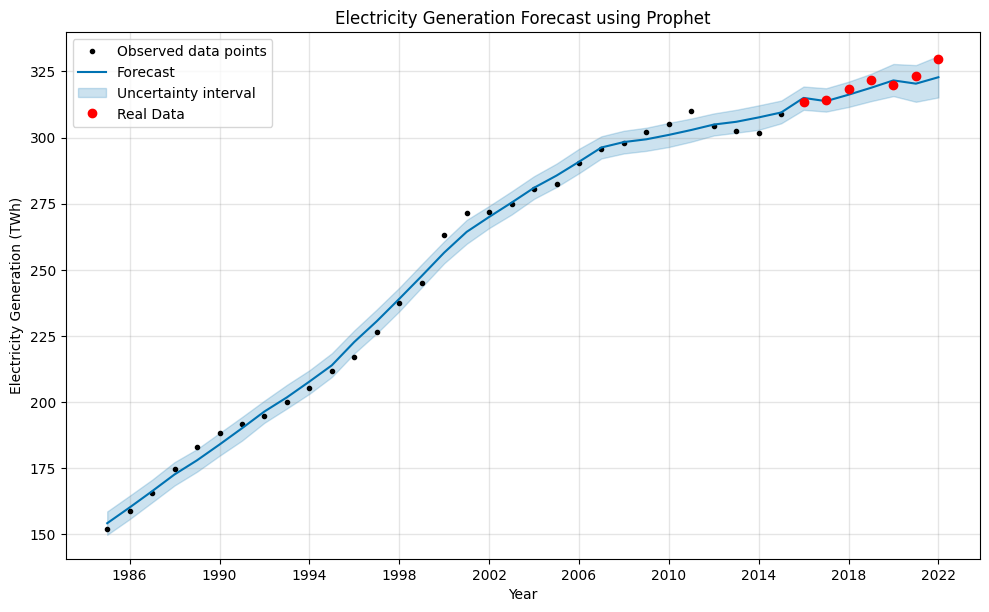

In [41]:
country_filt = oceania_continente[["electricity_generation"]]

size = best_size
index = round(size*country_filt.shape[0])
country_train = country_filt.iloc[:index]
country_test = country_filt.iloc[index:]


df_prophet_country = country_train
df_prophet_country.index = pd.to_datetime(df_prophet_country.index, format='%Y')
# Asegurarse de que el índice de df_test sea un DatetimeIndex
country_test.index = pd.to_datetime(country_test.index, format='%Y')  # Si el índice son solo años


# Reformatear los datos para Prophet (usando df_train para entrenamiento)
df_prophet_country = country_train.reset_index().rename(columns={"Year": "ds", "electricity_generation": "y"})

 # Ajustar el modelo
model_prophet = Prophet()

model_prophet.fit(df_prophet_country)

# Crear un DataFrame de fechas futuras
future = model_prophet.make_future_dataframe(periods=country_test.shape[0], freq="Y")

# Generar predicciones
forecast = model_prophet.predict(future).set_index(country_filt.index)

# Graficar resultados
fig = model_prophet.plot(forecast)
plt.title("Electricity Generation Forecast using Prophet")

#Trazar los valores reales de df_test en la misma gráfica
plt.plot(country_test.index,country_test["electricity_generation"], 'o', color='red', label='Real Data')
# Configuración del gráfico
plt.xlabel("Year")
plt.ylabel("Electricity Generation (TWh)")
plt.grid(True)
plt.legend()  # Mostrar la leyenda para las dos series
plt.show()

In [45]:
country_test

,electricity_generation
Year,
2016-01-01,313.30002
2017-01-01,314.34000
2018-01-01,318.54000
2019-01-01,321.65000
2020-01-01,320.00000
2021-01-01,323.39000
2022-01-01,329.52997


In [47]:
r2_score(forecast["yhat"][31:]

Year
2016    314.990795
2017    313.759297
2018    316.188551
2019    318.805001
2020    321.606001
2021    320.374503
2022    322.803756
Name: yhat, dtype: float64